In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

## Configuration

Specify the directories containing Elementary Effects results.
Each directory should contain CSV files like `ee_summary_*.csv`.

In [29]:
# === CONFIGURE YOUR DATA DIRECTORIES HERE ===
DATA_DIRS = [
    Path('../../outputs/20251114_155117_elementary_effects_lump'),
    Path('../../outputs/20251114_155146_elementary_effects_T_seeded'),
]

# Verify directories exist
for d in DATA_DIRS:
    if not d.exists():
        print(f"⚠️  Directory not found: {d}")
    else:
        print(f"✅ Found: {d}")

✅ Found: ../../outputs/20251114_155117_elementary_effects_lump
✅ Found: ../../outputs/20251114_155146_elementary_effects_T_seeded


## Load Data

Load all summary CSV files from the specified directories.

In [30]:
def load_ee_summary_files(data_dirs: List[Path]) -> Dict[str, pd.DataFrame]:
    """
    Load all ee_summary_*.csv files from specified directories.
    
    Returns:
        Dictionary with keys like 'lump_t_startup', 'T_seeded_unrealized_profits'
    """
    data = {}
    
    for data_dir in data_dirs:
        if not data_dir.exists():
            continue
        
        # Determine model type from directory name
        dir_name = data_dir.name.lower()
        if 'lump' in dir_name:
            model_type = 'lump'
        elif 't_seeded' in dir_name or 'tseeded' in dir_name:
            model_type = 'T_seeded'
        else:
            model_type = 'unknown'
        
        # Find all summary CSV files
        summary_files = list(data_dir.glob('ee_summary_*.csv'))
        
        for file_path in summary_files:
            # Extract metric name from filename
            metric = file_path.stem.replace('ee_summary_', '')
            
            # Load data
            df = pd.read_csv(file_path)
            
            # Add model type column
            df['model_type'] = model_type
            df['metric'] = metric
            
            # Store with composite key
            key = f"{model_type}_{metric}"
            data[key] = df
            
            print(f"   Loaded {model_type} / {metric}: {len(df)} parameters")
    
    return data

# Load all data
print("Loading Elementary Effects summary data...")
ee_data = load_ee_summary_files(DATA_DIRS)
print(f"\n✅ Loaded {len(ee_data)} datasets")

Loading Elementary Effects summary data...
   Loaded lump / t_startup: 13 parameters
   Loaded lump / unrealized_profits: 13 parameters
   Loaded T_seeded / t_startup: 13 parameters
   Loaded T_seeded / unrealized_profits: 13 parameters

✅ Loaded 4 datasets


## Helper Functions for Plotting

In [31]:
def get_metric_label(metric: str) -> str:
    """Get pretty label for metric."""
    labels = {
        'unrealized_profits': r'$G$ (Unrealized Profits)',
        't_startup': r'$t_{startup}$ (Startup Time)',
        'Q_DD': r'$Q_{DD}$ (DD Gain)',
        'Q_DT_eq': r'$Q_{DT,eq}$ (DT Equilibrium Gain)',
        'E_lost': r'$E_{lost}$ (Energy Lost)',
    }
    return labels.get(metric, metric.replace('_', ' ').title())

def get_model_label(model_type: str) -> str:
    """Get pretty label for model type."""
    labels = {
        'lump': 'Lump Startup',
        'T_seeded': 'T-seeded Startup',
        'unknown': 'Unknown Model'
    }
    return labels.get(model_type, model_type)

def plot_ee_bar_subplot(ax, df: pd.DataFrame, metric: str, model_type: str, max_params: int = 10):
    """Plot μ* bar chart in a subplot."""
    # Sort by mu_star and take top parameters
    df_sorted = df.sort_values('mu_star', ascending=False).head(max_params)
    
    # Filter out near-zero values
    df_sorted = df_sorted[df_sorted['mu_star'] > 1e-6]
    
    if len(df_sorted) == 0:
        ax.text(0.5, 0.5, 'No significant effects', 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
        return
    
    # Create bar plot
    y_pos = np.arange(len(df_sorted))
    
    # Plot bars with error bars (95% CI)
    ax.barh(y_pos, df_sorted['mu_star'], 
           xerr=df_sorted['ci95_star'], 
           color='steelblue', alpha=0.7, capsize=3)
    
    # Set labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_sorted['parameter_latex'])
    ax.set_xlabel(r'$\mu^*$ (Mean |Effect|)')
    ax.grid(True, axis='x', alpha=0.3)
    ax.set_axisbelow(True)

def plot_ee_morris_subplot(ax, df: pd.DataFrame, metric: str, model_type: str, max_params: int = 10):
    """Plot Morris scatter (μ* vs σ*) in a subplot."""
    # Take top parameters by mu_star
    df_sorted = df.sort_values('mu_star', ascending=False).head(max_params)
    
    # Filter out near-zero values
    df_sorted = df_sorted[(df_sorted['mu_star'] > 1e-6) & (df_sorted['sigma_star'] > 1e-6)]
    
    if len(df_sorted) == 0:
        ax.text(0.5, 0.5, 'No significant effects', 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
        return
    
    # Scatter plot
    ax.scatter(df_sorted['mu_star'], df_sorted['sigma_star'], 
              s=100, c='steelblue', alpha=0.7, edgecolors='black', linewidths=1)
    
    # Add labels for top 5 parameters
    for idx, row in df_sorted.head(5).iterrows():
        ax.annotate(row['parameter_latex'], 
                   (row['mu_star'], row['sigma_star']),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=8, alpha=0.8)
    
    ax.set_xlabel(r'$\mu^*$ (Mean |Effect|)')
    ax.set_ylabel(r'$\sigma^*$ (Std. Deviation)')
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

## Create Combined μ* Bar Plot

Create a grid of subplots showing μ* (importance) for each model-metric combination.
- **Rows**: Model types (T-seeded, Lump)
- **Columns**: Metrics (G, t_startup, etc.)

Model types: ['T_seeded', 'lump']
Metrics: ['t_startup', 'unrealized_profits']

✅ Saved combined μ* plot: ../../outputs/20251114_155117_elementary_effects_lump/ee_combined_mustar_comparison.png

✅ Saved combined μ* plot: ../../outputs/20251114_155117_elementary_effects_lump/ee_combined_mustar_comparison.png


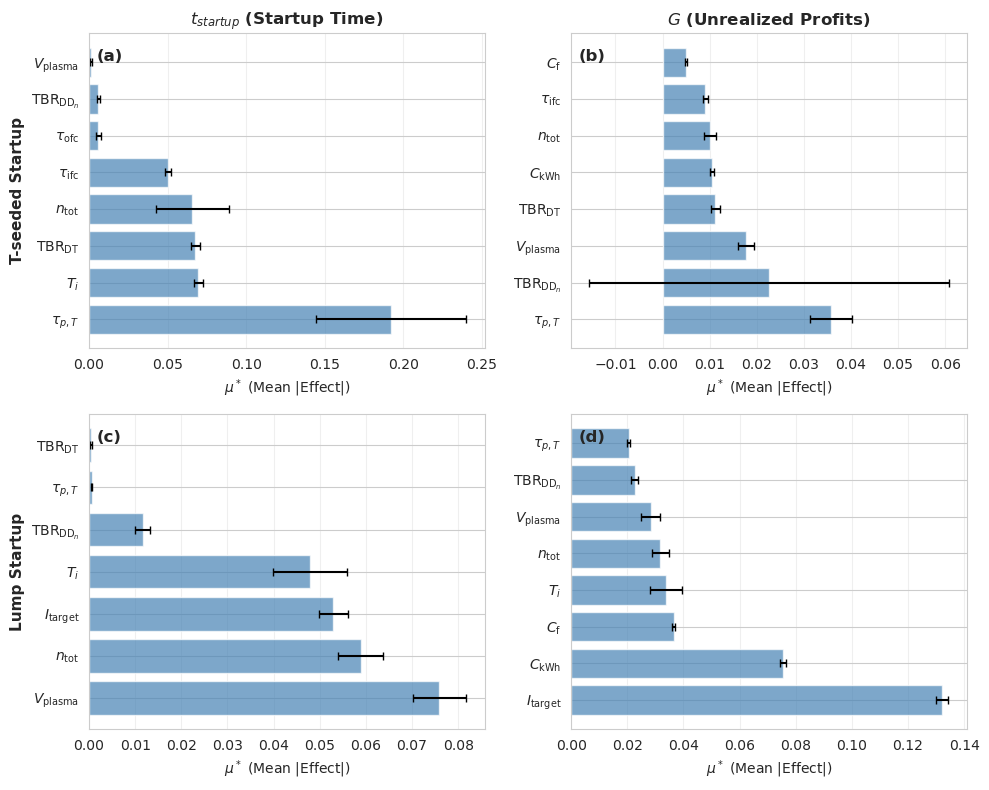

In [32]:
# Extract unique model types and metrics
model_types = sorted(set(df['model_type'].iloc[0] for df in ee_data.values()))
metrics = sorted(set(df['metric'].iloc[0] for df in ee_data.values()))

print(f"Model types: {model_types}")
print(f"Metrics: {metrics}")

# Create figure with subplots
n_rows = len(model_types)
n_cols = len(metrics)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), squeeze=False)

# Plot each combination
for i, model_type in enumerate(model_types):
    for j, metric in enumerate(metrics):
        ax = axes[i, j]
        key = f"{model_type}_{metric}"
        
        # Set title for top row (metrics)
        if i == 0:
            ax.set_title(get_metric_label(metric), fontsize=12, fontweight='bold')
        
        # Set ylabel for first column (model types)
        if j == 0:
            ax.set_ylabel(get_model_label(model_type), fontsize=11, fontweight='bold')
        
        # Plot if data exists
        if key in ee_data:
            plot_ee_bar_subplot(ax, ee_data[key], metric, model_type, max_params=8)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])

# --- Add subplot letters (a), (b), ... ---
# Make robust to axes shape (1x1, 1xN, Nx1, NxM)
try:
    flat_axes = axes.ravel()
except Exception:
    flat_axes = np.array([axes]).ravel()

total = len(flat_axes)
letters = [f'({chr(ord("a") + k)})' for k in range(total)]
for idx, ax in enumerate(flat_axes):
    if idx < len(letters):
        ax.text(0.02, 0.95, letters[idx], transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', ha='left')

plt.tight_layout()

# Save figure
output_dir = DATA_DIRS[0] if DATA_DIRS else Path('.')
output_path = output_dir / 'ee_combined_mustar_comparison.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Saved combined μ* plot: {output_path}")
plt.show()

## Create Ranking Table

Create a summary table showing the top parameters for each model-metric combination.

In [33]:
# Create ranking table
ranking_rows = []

for key, df in ee_data.items():
    model_type = df['model_type'].iloc[0]
    metric = df['metric'].iloc[0]
    
    # Get top 5 parameters
    top_params = df.nlargest(5, 'mu_star')[['parameter', 'mu_star', 'sigma_star']]
    
    for rank, (idx, row) in enumerate(top_params.iterrows(), 1):
        ranking_rows.append({
            'Model': get_model_label(model_type),
            'Metric': get_metric_label(metric),
            'Rank': rank,
            'Parameter': row['parameter'],
            'μ*': f"{row['mu_star']:.4f}",
            'σ*': f"{row['sigma_star']:.4f}"
        })

ranking_df = pd.DataFrame(ranking_rows)

# Save to CSV
ranking_path = output_dir / 'ee_combined_rankings.csv'
ranking_df.to_csv(ranking_path, index=False)
print(f"\n✅ Saved rankings table: {ranking_path}")

# Display table
print("\nTop 5 Parameters by Model and Metric:")
display(ranking_df)


✅ Saved rankings table: ../../outputs/20251114_155117_elementary_effects_lump/ee_combined_rankings.csv

Top 5 Parameters by Model and Metric:


,Model,Metric,Rank,Parameter,μ*,σ*
0,Lump Startup,$t_{startup}$ (Startup Time),1,V_plasma,0.0760,0.2710
1,Lump Startup,$t_{startup}$ (Startup Time),2,n_tot,0.0589,0.2339
2,Lump Startup,$t_{startup}$ (Startup Time),3,I_target,0.0529,0.1480
3,Lump Startup,$t_{startup}$ (Startup Time),4,T_i,0.0479,0.3860
4,Lump Startup,$t_{startup}$ (Startup Time),5,TBR_DDn,0.0116,0.0767
5,Lump Startup,$G$ (Unrealized Profits),1,I_target,0.1321,0.1046
6,Lump Startup,$G$ (Unrealized Profits),2,price_of_electricity,0.0756,0.0511
7,Lump Startup,$G$ (Unrealized Profits),3,capacity_factor,0.0365,0.0292
8,Lump Startup,$G$ (Unrealized Profits),4,T_i,0.0338,0.2710
9,Lump Startup,$G$ (Unrealized Profits),5,n_tot,0.0318,0.1386


## Summary Statistics

Compare the number of significant parameters and effect magnitudes across models.

In [34]:
summary_rows = []

for key, df in ee_data.items():
    model_type = df['model_type'].iloc[0]
    metric = df['metric'].iloc[0]
    
    # Count significant parameters (μ* > threshold)
    threshold = df['mu_star'].max() * 0.1  # 10% of max
    n_significant = (df['mu_star'] > threshold).sum()
    
    summary_rows.append({
        'Model': get_model_label(model_type),
        'Metric': get_metric_label(metric),
        'N_Parameters': len(df),
        'N_Significant': n_significant,
        'Max_μ*': df['mu_star'].max(),
        'Mean_μ*': df['mu_star'].mean(),
        'Max_σ*': df['sigma_star'].max(),
        'Mean_σ*': df['sigma_star'].mean()
    })

summary_df = pd.DataFrame(summary_rows)

# Save to CSV
summary_path = output_dir / 'ee_combined_summary.csv'
summary_df.to_csv(summary_path, index=False)
print(f"\n✅ Saved summary statistics: {summary_path}")

# Display
print("\nSummary Statistics:")
display(summary_df.round(4))


✅ Saved summary statistics: ../../outputs/20251114_155117_elementary_effects_lump/ee_combined_summary.csv

Summary Statistics:


,Model,Metric,N_Parameters,N_Significant,Max_μ*,Mean_μ*,Max_σ*,Mean_σ*
0,Lump Startup,$t_{startup}$ (Startup Time),13,5,0.0760,0.0248,0.3860,0.1129
1,Lump Startup,$G$ (Unrealized Profits),13,9,0.1321,0.0395,0.2710,0.0848
2,T-seeded Startup,$t_{startup}$ (Startup Time),13,5,0.1922,0.0417,2.2997,0.3576
3,T-seeded Startup,$G$ (Unrealized Profits),13,9,0.0357,0.0118,1.8721,0.2253


## Done!

All combined plots and tables have been saved to the first data directory.

### Output Files:
- `ee_combined_mustar_comparison.png` - Grid of μ* bar plots
- `ee_combined_morris_comparison.png` - Grid of Morris scatter plots
- `ee_combined_rankings.csv` - Top 5 parameters for each case
- `ee_combined_summary.csv` - Summary statistics

### Next Steps:
1. Adjust `max_params` in plotting functions to show more/fewer parameters
2. Customize colors and styles in the helper functions
3. Add more metrics or model types by updating `DATA_DIRS`

## Create Combined Box Plots

Create a grid of box plots showing the distribution of elementary effects for each model-metric combination.
- **Rows**: Model types (T-seeded, Lump)
- **Columns**: Metrics (G, t_startup, etc.)


/tmp/ipykernel_256228/1235641524.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"${label.strip('$')}$" for label in latex_order], fontsize=10)
/tmp/ipykernel_256228/1235641524.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"${label.strip('$')}$" for label in latex_order], fontsize=10)
/tmp/ipykernel_256228/1235641524.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"${label.strip('$')}$" for label in latex_order], fontsize=10)
/tmp/ipykernel_256228/1235641524.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"${label.strip('$')}$" for label in latex_order


✅ Saved combined box plot: ../../outputs/20251114_155117_elementary_effects_lump/ee_combined_boxplot_comparison.png


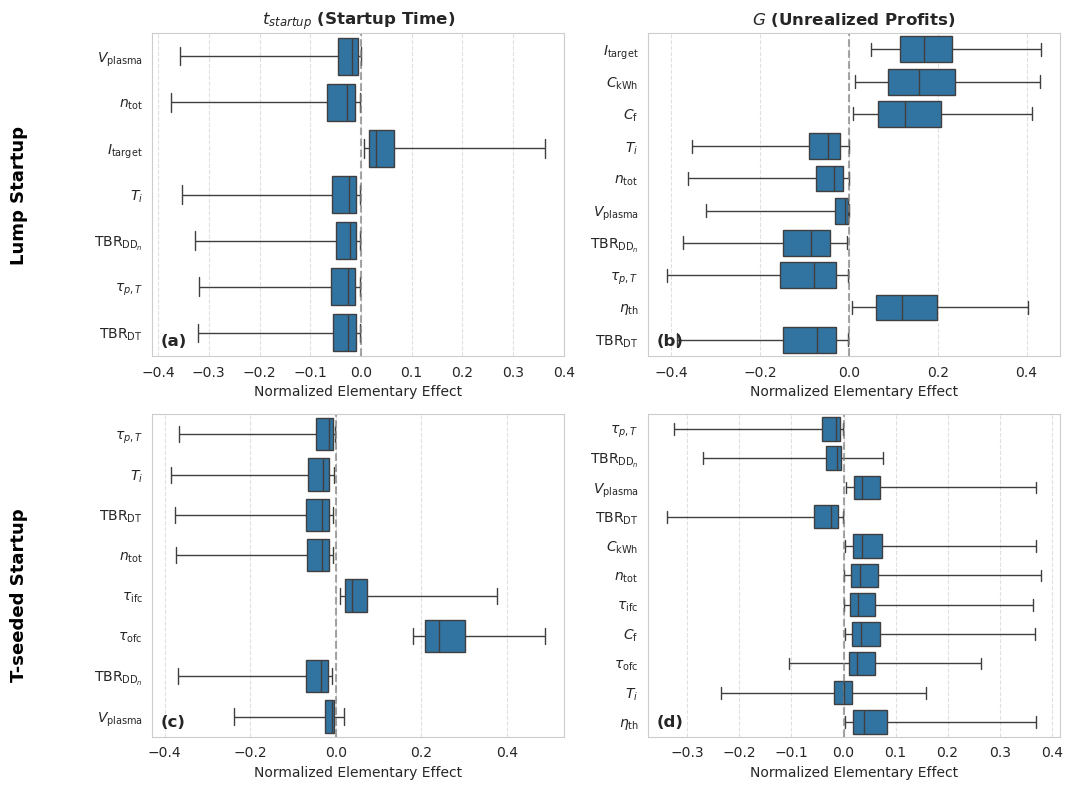

In [36]:
# --- Ensure model_types order matches DATA_DIRS order ---
# This guarantees that the row order and labels match the data source for each row.

import matplotlib as mpl
mpl.rcParams['text.usetex'] = False  # Use mathtext, not full LaTeX

from src.registry import parameter_registry as _registry

def _get_latex_name(param_name):
    try:
        return _registry.get_symbol(param_name)
    except Exception:
        return param_name

# === USER FLAG: Show mu* values on box plots? ===
SHOW_MU_STAR_ON_BOX = False  # Set to False to hide mu* values on the right of each box

# Parameters to exclude for t_startup calculation
EXCLUDE_TSTARTUP = {'Cf', 'eta_th', 'CkWh'}

model_types = []
for d in DATA_DIRS:
    dir_name = d.name.lower()
    if 'lump' in dir_name:
        model_types.append('lump')
    elif 't_seeded' in dir_name or 'tseeded' in dir_name:
        model_types.append('T_seeded')
    else:
        model_types.append('unknown')

fig, axes = plt.subplots(len(model_types), n_cols, figsize=(5*n_cols, 4*len(model_types)), squeeze=False)

for i, model_type in enumerate(model_types):
    fig.text(-0.06, (len(model_types) - i - 0.5) / len(model_types), get_model_label(model_type),
             va='center', ha='center', rotation=90, fontsize=13, fontweight='bold', color='black')

for i, (model_type, data_dir) in enumerate(zip(model_types, DATA_DIRS)):
    for j, metric in enumerate(metrics):
        ax = axes[i, j]
        key = f"{model_type}_{metric}"
        
        if i == 0:
            ax.set_title(get_metric_label(metric), fontsize=12, fontweight='bold')
        ax.set_ylabel('')
        
        if key in ee_data:
            raw_path = data_dir / f'ee_raw_effects_{metric}.csv'
            if raw_path.exists():
                raw_df = pd.read_csv(raw_path)
                mu_star = ee_data[key].set_index('parameter')['mu_star'].to_dict()
                norm_df_list = []
                latex_map = {}
                for param in raw_df['parameter'].unique():
                    # Exclude parameters for t_startup
                    if metric == 't_startup' and param in EXCLUDE_TSTARTUP:
                        continue
                    # Exclude parameters with zero importance
                    if mu_star.get(param, 0) == 0:
                        continue
                    param_df = raw_df[raw_df['parameter'] == param].copy()
                    values = param_df['elementary_effect'].values
                    q1, q3 = np.percentile(values, [2.5, 97.5])
                    iqr = q3 - q1
                    lower = q1 - 1.5 * iqr
                    upper = q3 + 1.5 * iqr
                    filtered = values[(values >= lower) & (values <= upper)]
                    if np.mean(np.abs(filtered)) > 1e5:
                        output_range = ee_data[key].get('output_range', 1.0)
                        if output_range == 0:
                            output_range = 1.0
                        filtered = filtered / output_range
                    max_abs = np.max(np.abs(filtered)) if len(filtered) > 0 else 1.0
                    if max_abs > 0:
                        filtered = filtered / max_abs
                    latex_name = _get_latex_name(param)
                    latex_map[param] = latex_name
                    norm_param_df = pd.DataFrame({
                        'Parameter': [param] * len(filtered),
                        'elementary_effect': filtered
                    })
                    norm_df_list.append(norm_param_df)
                if norm_df_list:
                    norm_df = pd.concat(norm_df_list, ignore_index=True)
                    param_list = list(norm_df['Parameter'].unique())
                    param_order = sorted(param_list, key=lambda p: (-(mu_star.get(p, 0)), p))
                    latex_order = [latex_map[p] for p in param_order]
                    norm_df['Parameter_latex'] = norm_df['Parameter'].map(latex_map)
                    if latex_order:
                        sns.boxplot(x='elementary_effect', y='Parameter_latex', data=norm_df[norm_df['Parameter'].isin(param_order)],
                                    order=latex_order, orient='h', showfliers=False, whis=[2.5, 97.5], ax=ax)
                        ax.axvline(x=0, color='gray', linestyle='--', alpha=0.7)
                        ax.grid(True, linestyle='--', alpha=0.6, axis='x')
                        ax.set_xlabel('Normalized Elementary Effect')
                        ax.set_ylabel('')
                        ax.set_yticklabels([f"${label.strip('$')}$" for label in latex_order], fontsize=10)
                        if SHOW_MU_STAR_ON_BOX:
                            for y_idx, param_latex in enumerate(latex_order):
                                orig_param = param_order[y_idx]
                                mu_val = mu_star.get(orig_param, 0)
                                ax.text(0.98, y_idx, f'μ*={mu_val:.4f}',
                                        transform=ax.get_yaxis_transform(),
                                        ha='right', va='center', fontsize=9,
                                        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.7))
                    else:
                        ax.text(0.5, 0.5, 'No significant effects', ha='center', va='center', transform=ax.transAxes)
                        ax.set_xticks([])
                        ax.set_yticks([])
                else:
                    ax.text(0.5, 0.5, 'No valid data', ha='center', va='center', transform=ax.transAxes)
                    ax.set_xticks([])
                    ax.set_yticks([])
            else:
                ax.text(0.5, 0.5, 'No raw data', ha='center', va='center', transform=ax.transAxes)
                ax.set_xticks([])
                ax.set_yticks([])
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])

# --- Add subplot letters (a), (b), ... for the box plot grid ---
try:
    flat_axes = axes.ravel()
except Exception:
    flat_axes = np.array([axes]).ravel()

total = len(flat_axes)
letters = [f'({chr(ord("a") + k)})' for k in range(total)]
for idx, ax in enumerate(flat_axes):
    if idx < len(letters):
        ax.text(0.02, 0.02, letters[idx], transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='bottom', ha='left')

plt.tight_layout()

output_path = output_dir / 'ee_combined_boxplot_comparison.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Saved combined box plot: {output_path}")
plt.show()